In [5]:
# ============================================================
# PHASE 2: Exploratory Data Analysis
# Dataset: Telco Customer Churn
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Plot styling
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 5)

print("All libraries loaded successfully ✅")

All libraries loaded successfully ✅


In [6]:
# Load dataset
df = pd.read_csv('../data/raw/telco_churn_raw.csv')

# Basic inspection
print("Shape:", df.shape)
print("\nColumn Names:\n", df.columns.tolist())
print("\nFirst 5 rows:")
df.head()

Shape: (7043, 21)

Column Names:
 ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

First 5 rows:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [7]:
print("=== Data Types ===")
print(df.dtypes)

print("\n=== Missing Values ===")
print(df.isnull().sum())

print("\n=== Duplicate Rows ===")
print(df.duplicated().sum())

=== Data Types ===
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

=== Missing Values ===
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
Pap

In [8]:
# TotalCharges has spaces instead of NaN — fix it
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Check how many NaNs appeared
print("NaN in TotalCharges after fix:", df['TotalCharges'].isnull().sum())

# Drop those rows (only 11 rows)
df.dropna(subset=['TotalCharges'], inplace=True)

print("New shape:", df.shape)

NaN in TotalCharges after fix: 11
New shape: (7032, 21)


In [9]:
print("=== Numerical Summary ===")
df.describe()

=== Numerical Summary ===


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7032.000000,7032.000000,7032.000000,7032.000000
mean,0.162400,32.421786,64.798208,2283.300441
std,0.368844,24.545260,30.085974,2266.771362
min,0.000000,1.000000,18.250000,18.800000
25%,0.000000,9.000000,35.587500,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.862500,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


In [10]:
print("=== Categorical Summary ===")
df.describe(include='object')

=== Categorical Summary ===


,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Churn
count,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032
unique,7032,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,2
top,7590-VHVEG,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,No
freq,1,3549,3639,4933,6352,3385,3096,3497,3087,3094,3472,2809,2781,3875,4168,2365,5163


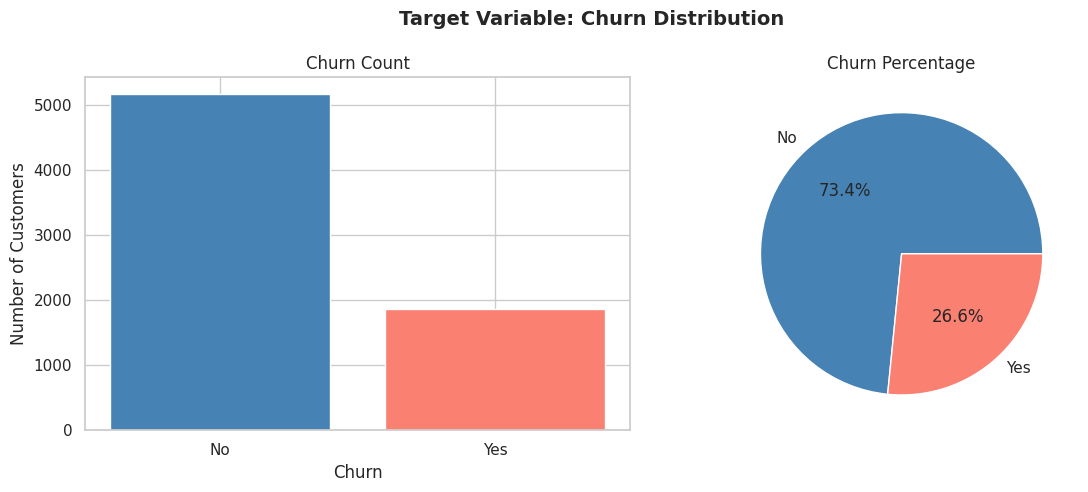


Churn Rate: 26.58%


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Count plot
churn_counts = df['Churn'].value_counts()
axes[0].bar(churn_counts.index, churn_counts.values, color=['steelblue', 'salmon'])
axes[0].set_title('Churn Count')
axes[0].set_xlabel('Churn')
axes[0].set_ylabel('Number of Customers')

# Pie chart
axes[1].pie(churn_counts.values, labels=churn_counts.index,
            autopct='%1.1f%%', colors=['steelblue', 'salmon'])
axes[1].set_title('Churn Percentage')

plt.suptitle('Target Variable: Churn Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/figures/churn_distribution.png', dpi=150)
plt.show()

print(f"\nChurn Rate: {churn_counts['Yes'] / len(df) * 100:.2f}%")

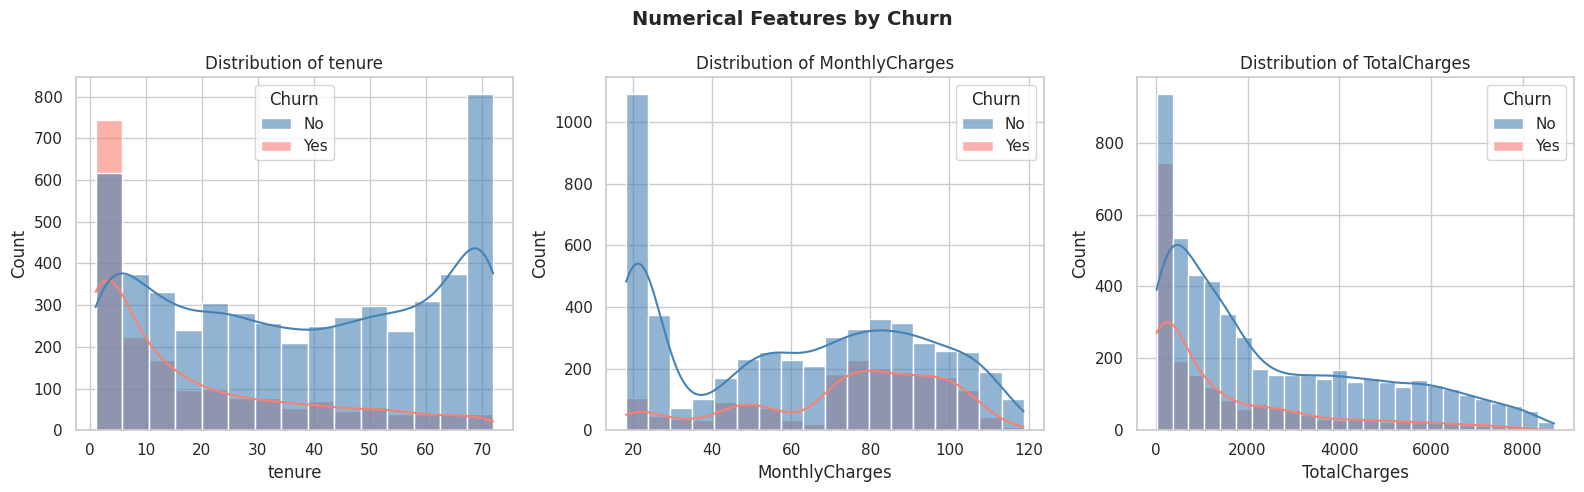

In [12]:
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, col in enumerate(num_cols):
    sns.histplot(data=df, x=col, hue='Churn', kde=True, ax=axes[i],
                 palette={'No': 'steelblue', 'Yes': 'salmon'}, alpha=0.6)
    axes[i].set_title(f'Distribution of {col}')

plt.suptitle('Numerical Features by Churn', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/figures/numerical_distributions.png', dpi=150)
plt.show()

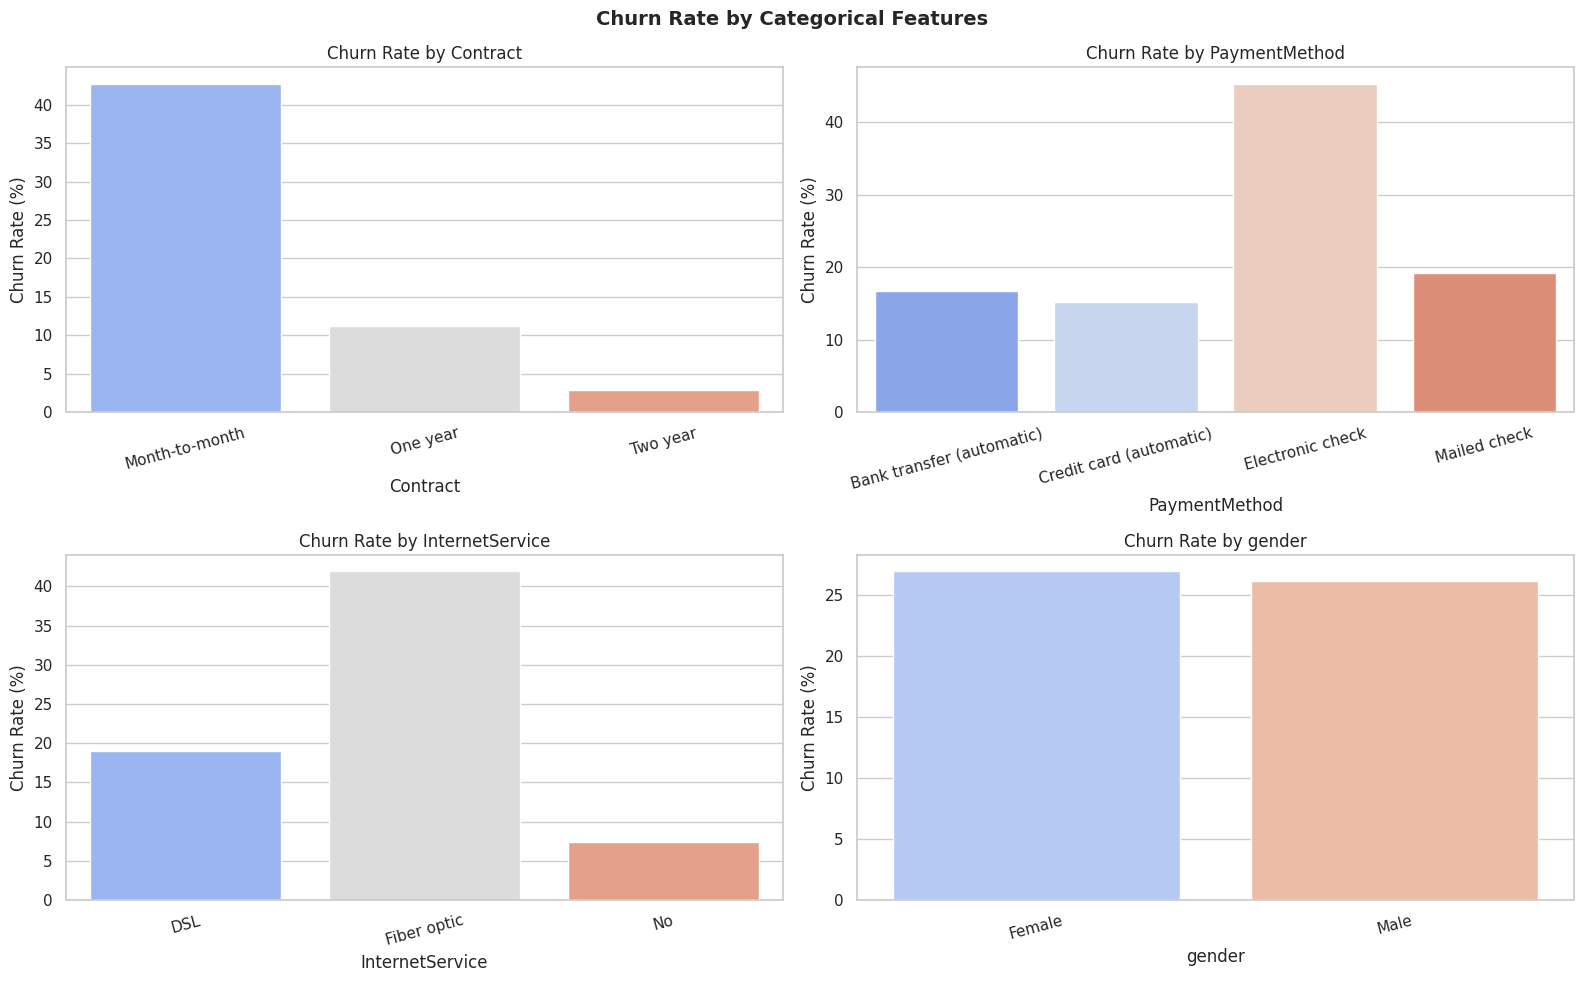

In [13]:
cat_cols = ['Contract', 'PaymentMethod', 'InternetService', 'gender']

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    churn_rate = df.groupby(col)['Churn'].apply(
        lambda x: (x == 'Yes').sum() / len(x) * 100
    ).reset_index()
    churn_rate.columns = [col, 'ChurnRate']
    
    sns.barplot(data=churn_rate, x=col, y='ChurnRate', ax=axes[i],
                palette='coolwarm')
    axes[i].set_title(f'Churn Rate by {col}')
    axes[i].set_ylabel('Churn Rate (%)')
    axes[i].tick_params(axis='x', rotation=15)

plt.suptitle('Churn Rate by Categorical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/figures/categorical_churn_rates.png', dpi=150)
plt.show()

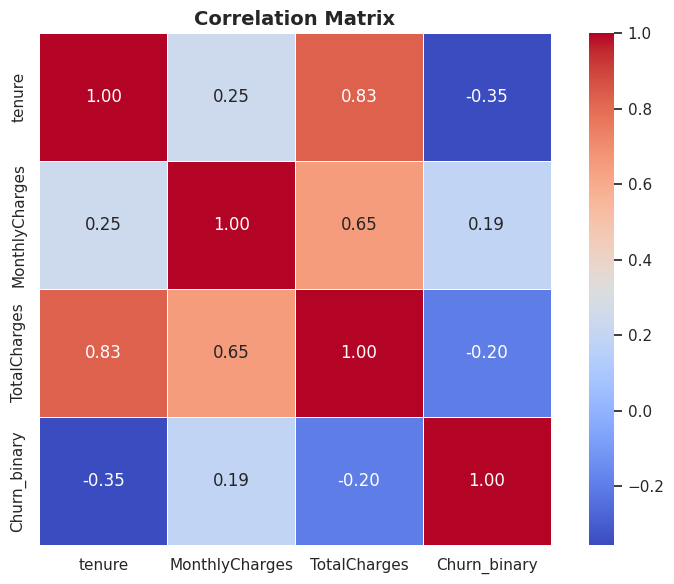

In [14]:
# Encode Churn for correlation
df['Churn_binary'] = df['Churn'].map({'Yes': 1, 'No': 0})

corr = df[['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn_binary']].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            square=True, linewidths=0.5)
plt.title('Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/figures/correlation_heatmap.png', dpi=150)
plt.show()

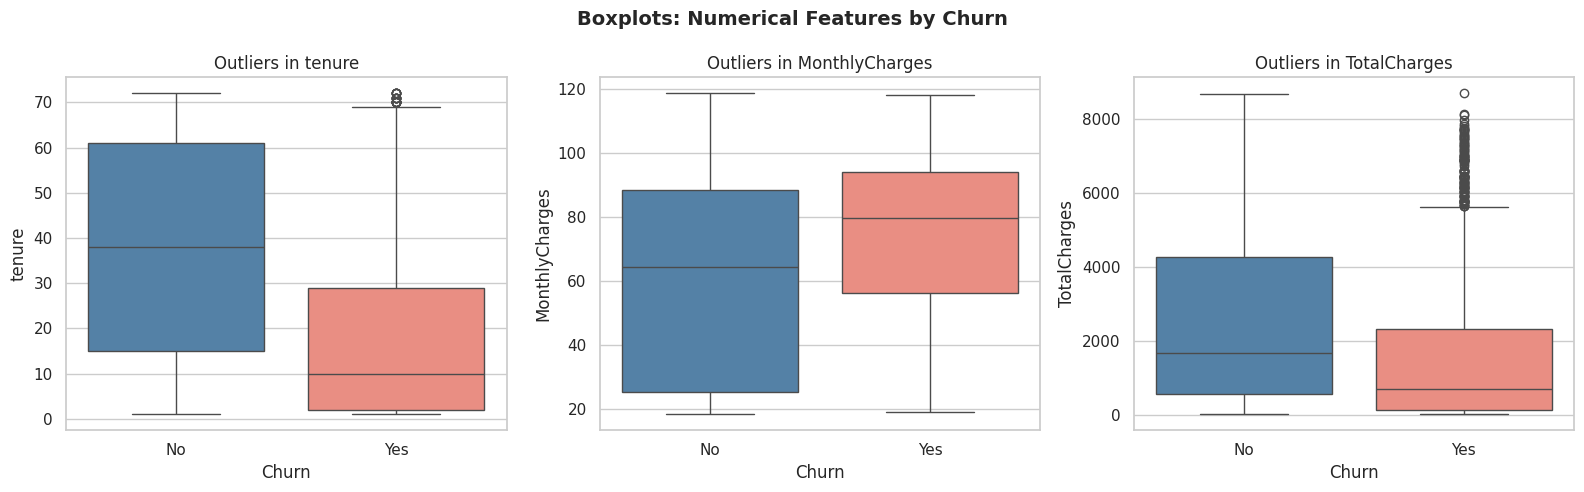

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, col in enumerate(num_cols):
    sns.boxplot(data=df, x='Churn', y=col, ax=axes[i],
                palette={'No': 'steelblue', 'Yes': 'salmon'})
    axes[i].set_title(f'Outliers in {col}')

plt.suptitle('Boxplots: Numerical Features by Churn', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/figures/boxplots.png', dpi=150)
plt.show()

In [16]:
# Drop the helper column before saving
df.drop(columns=['Churn_binary'], inplace=True)

# Save cleaned version
df.to_csv('../data/cleaned/telco_churn_cleaned.csv', index=False)
print("Cleaned dataset saved ✅")
print("Final shape:", df.shape)

Cleaned dataset saved ✅
Final shape: (7032, 21)
